# ***KELOMPOK THE GACORS***
---
Notebook ini telah di konfigurasi agar langsung bisa di run tanpa harus melakukan setting setting path atau yang lainya.

`note` : Dataset yang didownload sudah termasuk hasil dari kode YOLO yang seluruh kode nya di jadikan koment di bagian `IMAGE PREPARATION`

# ***IMPORT DEPENDENCIES***
---

In [ ]:
!pip install evaluate -q
# !pip install ultralytics -q # untuk menggunakan yolov8-face

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.5 MB/s eta 0:00:00


In [10]:
from pathlib import Path
from collections import Counter
import os
import gc
import math
import random
import zipfile

import cv2
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T

from PIL import Image
from PIL import Image as PILImage
from tqdm.auto import tqdm

from datasets import load_dataset
import evaluate
from huggingface_hub import login
# from ultralytics import YOLO  # untuk menggunakan yolov8-face

from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    )

from torchvision.transforms import (
    Compose,
    Resize,
    RandomHorizontalFlip,
    ColorJitter,
    GaussianBlur,
    ToTensor,
    Normalize,
    )

from transformers import (
    AutoImageProcessor,
    AutoModel,
    AutoModelForImageClassification,
    TrainingArguments,
    Trainer,
    set_seed,
    EarlyStoppingCallback,
    )
from transformers.utils.notebook import NotebookProgressCallback
import zipfile

from warnings import filterwarnings
filterwarnings('ignore')

## *Donwload data*

In [ ]:
DATA_WORKDIR = Path('/kaggle/working/data')
DATA_WORKDIR.mkdir(parents=True, exist_ok=True)

DATA_ZIP_PATH = DATA_WORKDIR / 'dataset.zip'
SAMPLE_SUB_LOCAL_PATH = DATA_WORKDIR / 'sample_submission.csv'
BEST_MODEL_PATH = Path('/kaggle/working/best_model.pt')
EXTRACT_DIR = DATA_WORKDIR / 'dataset_extracted'

# Dataset after relabeled and croppeed with yolo
!gdown --fuzzy https://drive.google.com/file/d/16ycItHcoercpqJvGadd7QkEuM9IBHCUH/view?usp=drive_link -O {DATA_ZIP_PATH}

# Sample submission
!gdown --fuzzy https://drive.google.com/file/d/17gdVhILXB-k7flBAJoHNBYuzpgE5070z/view?usp=drive_link -O {SAMPLE_SUB_LOCAL_PATH}

# Best model hasil training sebelumnya
!gdown --fuzzy https://drive.google.com/file/d/1hk1n79fNK5gBDW_H6c-Q4zMXApsSeiyL/view?usp=sharing -O {BEST_MODEL_PATH}

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(DATA_ZIP_PATH, 'r') as zf:
    zf.extractall(EXTRACT_DIR)

candidates = list(EXTRACT_DIR.rglob('cropped_dataset'))
if not candidates:
    raise FileNotFoundError('Folder cropped_dataset tidak ditemukan setelah ekstrak zip.')

CROPPED_DATASET_DIR = candidates[0]
print('CROPPED_DATASET_DIR =', CROPPED_DATASET_DIR)
print('Subfolder tersedia:', [p.name for p in CROPPED_DATASET_DIR.iterdir() if p.is_dir()])

Downloading...
From (original): https://drive.google.com/uc?id=16ycItHcoercpqJvGadd7QkEuM9IBHCUH
From (redirected): https://drive.google.com/uc?id=16ycItHcoercpqJvGadd7QkEuM9IBHCUH&confirm=t&uuid=4ecd5922-4cbd-4cc2-8cfd-624ef21749a5
To: /kaggle/working/data/dataset.zip
100%|██████████████████████████████████████| 1.37G/1.37G [00:24<00:00, 54.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=17gdVhILXB-k7flBAJoHNBYuzpgE5070z
To: /kaggle/working/data/sample_submission.csv
100%|██████████████████████████████████████| 5.57k/5.57k [00:00<00:00, 22.1MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1hk1n79fNK5gBDW_H6c-Q4zMXApsSeiyL
From (redirected): https://drive.google.com/uc?id=1hk1n79fNK5gBDW_H6c-Q4zMXApsSeiyL&confirm=t&uuid=f726e4a4-65b6-45dc-8d84-fd3f6e36bcbc
To: /kaggle/working/best_model.pt
100%|█████████████████████████████████████████| 807M/807M [00:07<00:00, 103MB/s]
CROPPED_DATASET_DIR = /kaggle/working/data/dataset_extracted/cropped_dataset
Subfolder 

## *Configuration*

In [37]:
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

DATA_TRAIN_DIR = CROPPED_DATASET_DIR / 'train_yolo'
DATA_TRAIN_FULL_DIR = CROPPED_DATASET_DIR / 'train_no_yolo'
DATA_TEST_DIR = CROPPED_DATASET_DIR / 'test_yolo'
DATA_TEST_FULL_DIR = CROPPED_DATASET_DIR / 'test_no_loyo'
SAMPLE_SUB_PATH = SAMPLE_SUB_LOCAL_PATH

MODEL_CHECKPOINT = 'facebook/dinov3-convnext-large-pretrain-lvd1689m'
OUTPUT_DIR = Path('/kaggle/working/outputs/dinov3_convnext_large')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for p in [DATA_TRAIN_DIR, DATA_TRAIN_FULL_DIR, DATA_TEST_DIR, DATA_TEST_FULL_DIR, SAMPLE_SUB_PATH]:
    if not p.exists():
        raise FileNotFoundError(f'Path tidak ditemukan: {p}')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('DEVICE:', DEVICE)
print('DATA_TRAIN_DIR:', DATA_TRAIN_DIR)
print('DATA_TRAIN_FULL_DIR:', DATA_TRAIN_FULL_DIR)
print('DATA_TEST_DIR:', DATA_TEST_DIR)
print('DATA_TEST_FULL_DIR:', DATA_TEST_FULL_DIR)
print('SAMPLE_SUB_PATH:', SAMPLE_SUB_PATH)

DEVICE: cuda
DATA_TRAIN_DIR: /kaggle/working/data/dataset_extracted/cropped_dataset/train_yolo
DATA_TRAIN_FULL_DIR: /kaggle/working/data/dataset_extracted/cropped_dataset/train_no_yolo
DATA_TEST_DIR: /kaggle/working/data/dataset_extracted/cropped_dataset/test_yolo
DATA_TEST_FULL_DIR: /kaggle/working/data/dataset_extracted/cropped_dataset/test_no_loyo
SAMPLE_SUB_PATH: /kaggle/working/data/sample_submission.csv


# ***IMAGE PREPARATION***
---
Awal awal kami melakukan deteksi wajah agar model dapat melihat dan fokus ke area wajah menggunakan model yolov8n-face.pt dan menghasilkan dataset baru.

In [ ]:
# # --- CONFIGURATION ---
# MODEL_URL = 'https://github.com/derronqi/yolov8-face/releases/download/v1.0/yolov8n-face.pt'
# MODEL_NAME = './model/yolov8n-face-lindevs.onnx'
# INPUT_TRAIN = Path('./data/relabeled_fix/train')
# INPUT_TEST = Path('./data/test')
# OUTPUT_BASE = Path('./data/relabeled_fix/cropped_dataset')
# TARGET_SIZE = (384, 384)
# PADDING_RATIO = 0.4

# def download_model(url, filename):
#     if not os.path.exists(filename):
#         print(f'Downloading {filename}...')
#         r = requests.get(url, stream=True)
#         with open(filename, 'wb') as f:
#             for chunk in r.iter_content(chunk_size=1024):
#                 if chunk:
#                     f.write(chunk)
#     return filename

# def get_robust_crop(image, box, padding_ratio):
#     img_h, img_w = image.shape[:2]
#     x1, y1, x2, y2 = map(int, box.xyxy[0])

#     w, h = x2 - x1, y2 - y1
#     pad = int(max(w, h) * padding_ratio)

#     nx1 = max(0, x1 - pad)
#     ny1 = max(0, y1 - pad)
#     nx2 = min(img_w, x2 + pad)
#     ny2 = min(img_h, y2 + pad)

#     return image[ny1:ny2, nx1:nx2]

# def main():
#     model_path = MODEL_NAME
#     model = YOLO(model_path)

#     print('\nProcessing TRAIN images...')
#     labels = [d for d in INPUT_TRAIN.iterdir() if d.is_dir()]

#     for label_dir in labels:
#         save_dir = OUTPUT_BASE / 'train' / label_dir.name
#         save_dir.mkdir(parents=True, exist_ok=True)

#         for img_path in tqdm(list(label_dir.glob('*.*')), desc=f'Label: {label_dir.name}'):
#             img = cv2.imread(str(img_path))
#             if img is None:
#                 continue

#             results = model(img, conf=0.45, verbose=False)

#             if len(results[0].boxes) > 0:
#                 best_box = max(
#                     results[0].boxes,
#                     key=lambda b: (b.xyxy[0][2] - b.xyxy[0][0]) * (b.xyxy[0][3] - b.xyxy[0][1])
#                 )
#                 crop = get_robust_crop(img, best_box, PADDING_RATIO)
#             else:
#                 crop = img

#             final_img = cv2.resize(crop, TARGET_SIZE, interpolation=cv2.INTER_LANCZOS4)
#             cv2.imwrite(str(save_dir / img_path.name), final_img)

#     print('\nProcessing TEST images...')
#     save_dir_test = OUTPUT_BASE / 'test'
#     save_dir_test.mkdir(parents=True, exist_ok=True)

#     for img_path in tqdm(list(INPUT_TEST.glob('*.*')), desc='Testing Set'):
#         img = cv2.imread(str(img_path))
#         if img is None:
#             continue

#         results = model(img, conf=0.45, verbose=False)

#         if len(results[0].boxes) > 0:
#             best_box = max(
#                 results[0].boxes,
#                 key=lambda b: (b.xyxy[0][2] - b.xyxy[0][0]) * (b.xyxy[0][3] - b.xyxy[0][1])
#             )
#             crop = get_robust_crop(img, best_box, PADDING_RATIO)
#         else:
#             crop = img

#         final_img = cv2.resize(crop, TARGET_SIZE, interpolation=cv2.INTER_LANCZOS4)
#         cv2.imwrite(str(save_dir_test / img_path.name), final_img)

# if __name__ == '__main__':
#     main()

# ***Load Dataset & Split Validasi***
---

## *Load Real Image and Pair YOLO Results*

In [43]:
raw_face = load_dataset('imagefolder', data_dir=str(DATA_TRAIN_DIR))
raw_full = load_dataset('imagefolder', data_dir=str(DATA_TRAIN_FULL_DIR))

face_ds = raw_face['train']
full_ds = raw_full['train']

assert len(face_ds) == len(full_ds)

for i in range(5):
    assert face_ds[i]['label'] == full_ds[i]['label'], f"Mismatch at {i}"

def add_face(example, idx):
    example['face_image'] = face_ds[idx]['image']
    return example

full_train = full_ds.map(
    add_face,
    with_indices=True,
    desc='Pairing face + full'
    )

split = full_train.train_test_split(
    test_size=0.2,
    seed=SEED,
    stratify_by_column='label'
    )

train_ds = split['train']
valid_ds = split['test']

Resolving data files:   0%|          | 0/1655 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Resolving data files:   0%|          | 0/1655 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Pairing face + full:   0%|          | 0/1655 [00:00<?, ? examples/s]

In [46]:
# Label
label_names = full_train.features['label'].names

id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in id2label.items()}

print('Jumlah train :', len(train_ds))
print('Jumlah valid :', len(valid_ds))
print('Label       :', label_names)

print(train_ds[0].keys())

Jumlah train : 1324
Jumlah valid : 331
Label       : ['fake_mannequin', 'fake_mask', 'fake_printed', 'fake_screen', 'fake_unknown', 'realperson']
dict_keys(['image', 'label', 'face_image'])


In [47]:
print("id2label:")
print(id2label)
print(Counter(train_ds['label']))

id2label:
{0: 'fake_mannequin', 1: 'fake_mask', 2: 'fake_printed', 3: 'fake_screen', 4: 'fake_unknown', 5: 'realperson'}
Counter({5: 360, 4: 297, 1: 225, 0: 169, 3: 160, 2: 113})


## *Label Distribution*

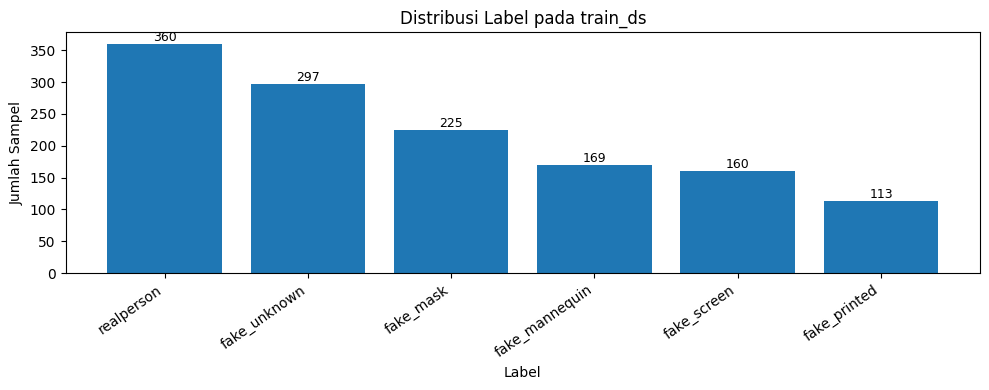

In [54]:
label_counts = pd.Series(train_ds['label']).value_counts().sort_values(ascending=False)
label_names_ordered = [id2label[i] for i in label_counts.index]

plt.figure(figsize=(10, 4))
bars = plt.bar(label_names_ordered, label_counts.values)
plt.title('Distribusi Label pada train_ds')
plt.xlabel('Label')
plt.ylabel('Jumlah Sampel')
plt.xticks(rotation=35, ha='right')

for bar, value in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, value, str(value), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


## *Contoh Gambar*

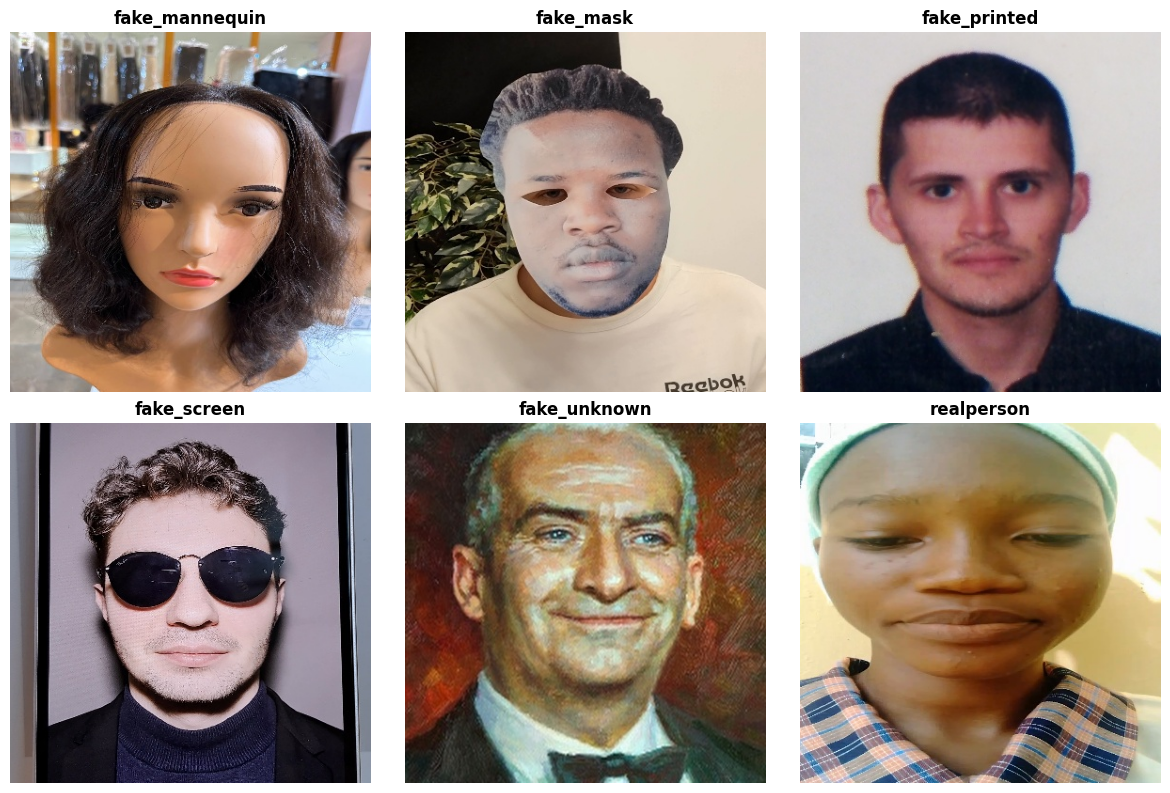

In [52]:
n_cols = 3
n_rows = int(np.ceil(len(label_names) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten() if len(label_names) > 1 else [axes]

for label_idx, label_name in enumerate(label_names):
    label_indices = [i for i, x in enumerate(train_ds['label']) if x == label_idx]

    if label_indices:
        sample_idx = label_indices[0]
        sample = train_ds[sample_idx]

        img = sample['face_image'].convert('RGB')
        axes[label_idx].imshow(img)
        axes[label_idx].set_title(label_name, fontsize=12, fontweight='bold')

    axes[label_idx].axis('off')

for idx in range(len(label_names), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# ***PREPROCESSING & AUGMENTATION***
---

In [ ]:
HF_TOKEN = os.getenv('HF_TOKEN', '')  # Simpan token di environment variable, jangan hardcode di notebook

if HF_TOKEN:
    login(HF_TOKEN)
else:
    print('HF_TOKEN tidak ditemukan. Login dilewati.')

In [22]:
processor = AutoImageProcessor.from_pretrained(MODEL_CHECKPOINT)
processor

preprocessor_config.json:   0%|          | 0.00/585 [00:00<?, ?B/s]

DINOv3ViTImageProcessorFast {
  "data_format": "channels_first",
  "default_to_square": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "DINOv3ViTImageProcessorFast",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

## *Fungsi untuk Transform*

In [23]:
size_cfg = processor.size
image_size = size_cfg.get('shortest_edge') or size_cfg.get('height') or 224

mean = processor.image_mean
std = processor.image_std

class AddGaussianNoise:
    def __init__(self, std=0.02, p=0.2):
        self.std = std
        self.p = p

    def __call__(self, tensor):
        if random.random() < self.p:
            return tensor + torch.randn_like(tensor) * self.std
        return tensor

class RandomJPEGCompression:
    def __init__(self, quality_range=(30, 85), p=1.0):
        self.quality_range = quality_range
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img

        from io import BytesIO
        buffer = BytesIO()
        quality = random.randint(*self.quality_range)

        img.save(buffer, format='JPEG', quality=quality)
        buffer.seek(0)

        return Image.open(buffer).convert('RGB')

class RandomLowResolution:
    def __init__(self, scale_range=(0.3, 0.7), p=1.0):
        self.scale_range = scale_range
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img

        w, h = img.size
        scale = random.uniform(*self.scale_range)

        new_w, new_h = int(w * scale), int(h * scale)
        img = img.resize((new_w, new_h), Image.BILINEAR)
        img = img.resize((w, h), Image.BILINEAR)

        return img

class RandomPixelation:
    def __init__(self, scale_range=(0.15, 0.35), p=1.0):
        self.scale_range = scale_range
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img

        w, h = img.size
        scale = random.uniform(*self.scale_range)

        small_w, small_h = int(w * scale), int(h * scale)
        img = img.resize((small_w, small_h), Image.NEAREST)
        img = img.resize((w, h), Image.NEAREST)

        return img

## *Transform Augmentation*

In [24]:
train_tfms = Compose([
    T.RandomResizedCrop(image_size, scale=(0.6, 1.0)),

    T.RandomApply([
        T.RandomChoice([
            RandomJPEGCompression(quality_range=(40, 90)),
            RandomLowResolution(scale_range=(0.5, 0.8)),
            GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
        ])
    ], p=0.2),

    RandomHorizontalFlip(p=0.5),

    T.RandomGrayscale(p=0.05),
    ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    ToTensor(),

    AddGaussianNoise(std=0.01, p=0.1),

    Normalize(mean=mean, std=std),
])

valid_tfms = Compose([
    Resize((image_size, image_size)),
    ToTensor(),
    Normalize(mean, std),
])

## *Preprocessing*

In [25]:
def preprocess_train(batch):
    pixel_values = []

    for img_full, img_face in zip(batch['image'], batch['face_image']):
        p = random.random()
        img = img_face if p < 0.5 else img_full

        img = img.convert('RGB')
        img = train_tfms(img)
        pixel_values.append(img)

    batch['pixel_values'] = pixel_values
    return batch

def preprocess_valid(batch):
    batch['pixel_values'] = [
        valid_tfms(img.convert('RGB'))
        for img in batch['face_image']
        ]
    return batch

train_ds = train_ds.with_transform(preprocess_train)
valid_ds = valid_ds.with_transform(preprocess_valid)

def collate_fn(examples):
    return {
        'pixel_values': torch.stack([x['pixel_values'] for x in examples]),
        'labels': torch.tensor([x['label'] for x in examples], dtype=torch.long),
        }

# ***MODEL, TRAINER, METRIC***
---

## *Custom Model*

In [26]:
backbone = AutoModel.from_pretrained(MODEL_CHECKPOINT)

class FocalLoss(nn.Module):
    def __init__(self, gamma=1.5):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(
            logits,
            targets,
            reduction='none'
            )
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

class DINOv3ConvNeXtClassifier(nn.Module):
    def __init__(self, backbone, num_classes, id2label=None, label2id=None):
        super().__init__()
        self.backbone = backbone

        hidden_dim = 1536
        print('Hidden dim:', hidden_dim)

        self.adapter = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
            )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
            )

        self.loss_fn = FocalLoss(gamma=1.5)
        self.id2label = id2label
        self.label2id = label2id

    def forward(self, pixel_values, labels=None):
        outputs = self.backbone(pixel_values=pixel_values)
        x = outputs.last_hidden_state.mean(dim=1)
        x = x + 0.3 * self.adapter(x)

        logits = self.classifier(x)

        loss = None
        if labels is not None:
            loss = self.loss_fn(logits, labels)

        return {'loss': loss, 'logits': logits}

config.json:   0%|          | 0.00/449 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/785M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/342 [00:00<?, ?it/s]

# ***TRAINING***
---

## *Setup Trainer*

In [27]:
model = DINOv3ConvNeXtClassifier(
    backbone,
    num_classes=len(label_names),
    id2label=id2label,
    label2id=label2id
)

acc_metric = evaluate.load('accuracy')
f1_metric = evaluate.load('f1')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = acc_metric.compute(predictions=preds, references=labels)['accuracy']
    macro_f1 = f1_metric.compute(predictions=preds, references=labels, average='macro')['f1']
    return {'accuracy': acc, 'macro_f1': macro_f1}

args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='steps',
    logging_steps=20,
    logging_first_step=True,

    learning_rate=1e-5,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,

    per_device_train_batch_size=32,
    gradient_accumulation_steps=1,

    per_device_eval_batch_size=16,
    num_train_epochs=10,

    weight_decay=0.02,
    max_grad_norm=1.0,

    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,

    remove_unused_columns=False,
    save_total_limit=1,

    fp16=torch.cuda.is_available(),
    report_to='none',

    dataloader_num_workers=0,
    seed=SEED,
    dataloader_pin_memory=True,
    dataloader_persistent_workers=False
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

Hidden dim: 1536


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [28]:
train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.005320,0.364476,0.870091,0.844948
2,0.231978,0.143106,0.933535,0.921687
3,0.095198,0.095678,0.954683,0.950197
4,0.050388,0.085853,0.963746,0.958603
5,0.047354,0.077204,0.960725,0.954944
6,0.034527,0.060971,0.969789,0.964066
7,0.011894,0.050378,0.975831,0.970766
8,0.014726,0.070597,0.969789,0.964066
9,0.008428,0.047795,0.975831,0.971435
10,0.006236,0.047519,0.975831,0.971435


TrainOutput(global_step=210, training_loss=0.145577305848045, metrics={'train_runtime': 1757.9417, 'train_samples_per_second': 7.514, 'train_steps_per_second': 0.119, 'total_flos': 0.0, 'train_loss': 0.145577305848045, 'epoch': 10.0})

In [ ]:
# Cleanup memory
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

In [ ]:
torch.save(trainer.model.state_dict(), "dinov3_convnext_large_yolo_faceFullTrainTest_final.pth")

# ***EVALUATION***
---

In [50]:
# Remove NotebookProgressCallback untuk evaluasi agar tidak error
trainer.remove_callback(NotebookProgressCallback)

eval_result = trainer.evaluate()
eval_result

{'eval_loss': 0.04779484495520592,
 'eval_accuracy': 0.9758308157099698,
 'eval_macro_f1': 0.9714345975177588,
 'eval_runtime': 31.4551,
 'eval_samples_per_second': 10.523,
 'eval_steps_per_second': 0.35,
 'epoch': 10.0}

In [29]:
model.eval()

DINOv3ConvNeXtClassifier(
  (backbone): DINOv3ConvNextModel(
    (stages): ModuleList(
      (0): DINOv3ConvNextStage(
        (downsample_layers): ModuleList(
          (0): Conv2d(3, 192, kernel_size=(4, 4), stride=(4, 4))
          (1): DINOv3ConvNextLayerNorm((192,), eps=1e-06, elementwise_affine=True)
        )
        (layers): ModuleList(
          (0-2): 3 x DINOv3ConvNextLayer(
            (depthwise_conv): Conv2d(192, 192, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=192)
            (layer_norm): DINOv3ConvNextLayerNorm((192,), eps=1e-06, elementwise_affine=True)
            (pointwise_conv1): Linear(in_features=192, out_features=768, bias=True)
            (activation_fn): GELUActivation()
            (pointwise_conv2): Linear(in_features=768, out_features=192, bias=True)
            (drop_path): Identity()
          )
        )
      )
      (1): DINOv3ConvNextStage(
        (downsample_layers): ModuleList(
          (0): DINOv3ConvNextLayerNorm((192,), eps=1e

## *Classification Report*

In [31]:
from torch.utils.data import DataLoader

all_preds = []

valid_loader = DataLoader(valid_ds, batch_size=16, collate_fn=collate_fn)

with torch.no_grad():
    for batch in tqdm(valid_loader, desc='Evaluating on valid_ds'):
        pixel_values = batch['pixel_values'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)

        outputs = model(pixel_values=pixel_values, labels=labels)
        logits = outputs['logits']
        preds = torch.argmax(logits, dim=-1).cpu().numpy().tolist()
        all_preds.extend(preds)

true_labels = valid_ds['label']
print(classification_report(true_labels, all_preds, target_names=label_names))

Evaluating on valid_ds:   0%|          | 0/21 [00:00<?, ?it/s]

                precision    recall  f1-score   support

fake_mannequin       0.98      0.98      0.98        43
     fake_mask       0.95      0.98      0.96        56
  fake_printed       0.93      0.93      0.93        28
   fake_screen       0.98      1.00      0.99        40
  fake_unknown       1.00      0.99      0.99        74
    realperson       0.99      0.97      0.98        90

      accuracy                           0.98       331
     macro avg       0.97      0.97      0.97       331
  weighted avg       0.98      0.98      0.98       331



## *Confusion Matrix & Heatmap*

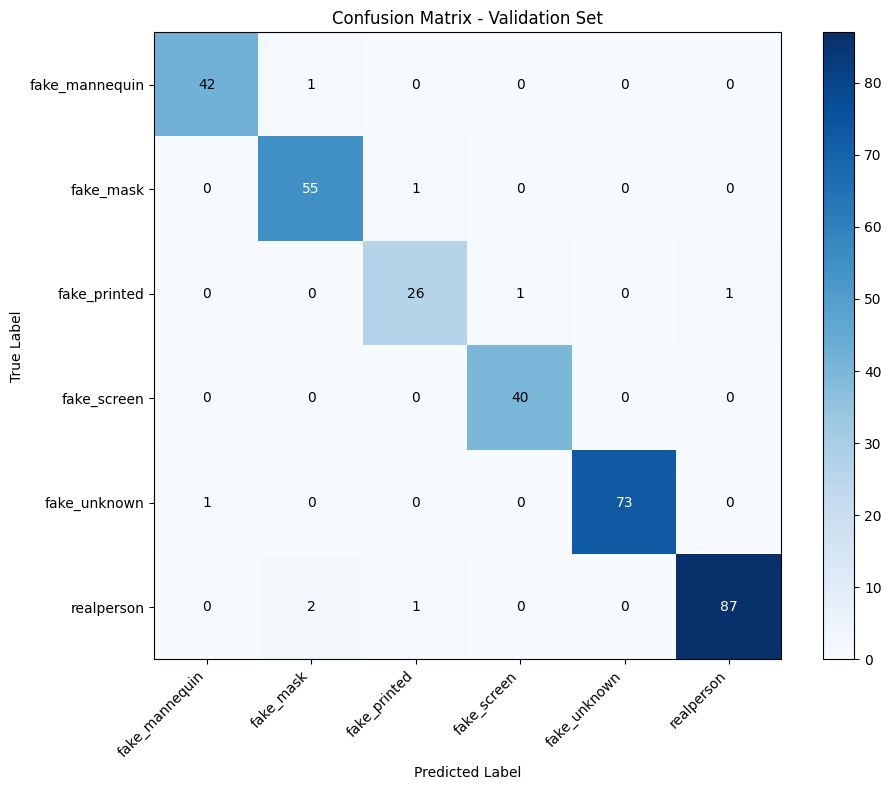

In [33]:
cm = confusion_matrix(true_labels, all_preds)

plt.figure(figsize=(10, 8))
im = plt.imshow(cm, cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Validation Set')
plt.colorbar(im)

plt.xticks(range(len(label_names)), label_names, rotation=45, ha='right')
plt.yticks(range(len(label_names)), label_names)

for i in range(len(label_names)):
    for j in range(len(label_names)):
        text = plt.text(j, i, cm[i, j], ha='center', va='center',
                       color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=10)

plt.tight_layout()
plt.show()

## *Visualization - Misclassified Examples*

Total errors: 8 / 331 (2.42%)


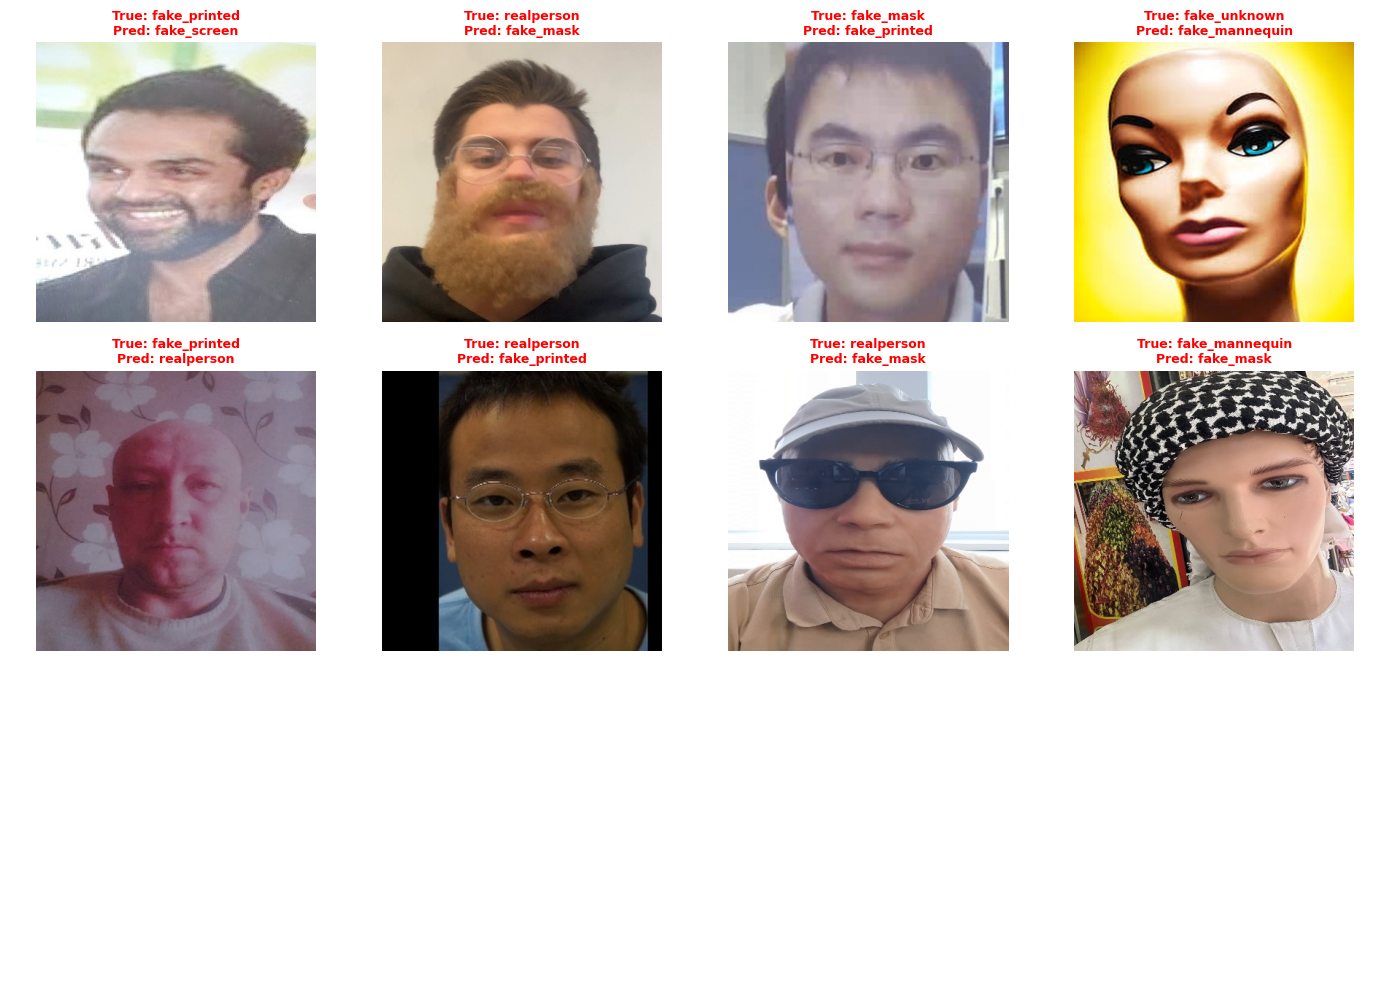

In [34]:
wrong_indices = [i for i in range(len(true_labels)) if true_labels[i] != all_preds[i]]
print(f'Total errors: {len(wrong_indices)} / {len(true_labels)} ({100*len(wrong_indices)/len(true_labels):.2f}%)')

n_show = min(12, len(wrong_indices))
random_wrong = random.sample(wrong_indices, n_show)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for idx, plot_idx in enumerate(random_wrong):
    sample = valid_ds[plot_idx]

    img = sample['face_image'].convert('RGB')
    true_label = label_names[true_labels[plot_idx]]
    pred_label = label_names[all_preds[plot_idx]]

    axes[idx].imshow(img)
    axes[idx].axis('off')
    axes[idx].set_title(f'True: {true_label}\nPred: {pred_label}',
                       fontsize=9, color='red', fontweight='bold')

for idx in range(n_show, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# ***Inference, Test, Submission***
---

untuk inference menggunakan model terbaik yang awal sudah di download dengan evaluasi paling bagus dari eksperiment yang kami lakukan

In [38]:
# MODEL_PATH = '/kaggle/working/dinov3_convnext_large_yolo_faceFullTrainTest_final.pth'
MODEL_PATH = BEST_MODEL_PATH # Gunakan model terbaik yang sudah di download dari Google Drive, hasil training sebelumnya

TEST_FULL_DIR = DATA_TEST_FULL_DIR

backbone = AutoModel.from_pretrained(MODEL_CHECKPOINT)
model = DINOv3ConvNeXtClassifier(
    backbone,
    num_classes=len(label_names),
    id2label=id2label,
    label2id=label2id
    )

state_dict = torch.load(MODEL_PATH, map_location='cpu')
model.load_state_dict(state_dict)
model = model.to(DEVICE)
model.eval()

submission = pd.read_csv(SAMPLE_SUB_PATH)
valid_exts = ['.jpg', '.jpeg', '.png', '.bmp', '.webp']

def find_image(image_id, base_dir):
    for ext in valid_exts:
        p = f'{base_dir}/{image_id}{ext}'
        if os.path.exists(p):
            return p
    return None

image_paths_crop = submission['id'].map(lambda x: find_image(x, DATA_TEST_DIR))
image_paths_full = submission['id'].map(lambda x: find_image(x, TEST_FULL_DIR))

scales = [224, 256, 288]
batch_size = 16
pred_labels = []

Loading weights:   0%|          | 0/342 [00:00<?, ?it/s]

Hidden dim: 1536


## *Inference Loop*

In [39]:
for i in tqdm(range(0, len(submission), batch_size)):
    batch_crop = image_paths_crop.iloc[i:i + batch_size].tolist()
    batch_full = image_paths_full.iloc[i:i + batch_size].tolist()

    imgs_crop = [
        PILImage.open(p).convert('RGB') if p else PILImage.new('RGB', (224, 224))
        for p in batch_crop
        ]
    imgs_full = [
        PILImage.open(p).convert('RGB') if p else PILImage.new('RGB', (224, 224))
        for p in batch_full
        ]

    probs_face = 0
    probs_full = 0
    count = 0

    with torch.no_grad(), torch.amp.autocast('cuda'):
        for size in scales:
            resized_face = [img.resize((size, size)) for img in imgs_crop]
            inputs_face = processor(images=resized_face, return_tensors='pt').to(DEVICE)
            logits_face_batch = model(**inputs_face)['logits']

            flipped_face = [img.transpose(PILImage.FLIP_LEFT_RIGHT) for img in resized_face]
            inputs_face_flip = processor(images=flipped_face, return_tensors='pt').to(DEVICE)
            logits_face_flip = model(**inputs_face_flip)['logits']

            probs_face += torch.softmax(logits_face_batch, dim=-1)
            probs_face += torch.softmax(logits_face_flip, dim=-1)

            resized_full = [img.resize((size, size)) for img in imgs_full]
            inputs_full = processor(images=resized_full, return_tensors='pt').to(DEVICE)
            logits_full_batch = model(**inputs_full)['logits']

            flipped_full = [img.transpose(PILImage.FLIP_LEFT_RIGHT) for img in resized_full]
            inputs_full_flip = processor(images=flipped_full, return_tensors='pt').to(DEVICE)
            logits_full_flip = model(**inputs_full_flip)['logits']

            probs_full += torch.softmax(logits_full_batch, dim=-1)
            probs_full += torch.softmax(logits_full_flip, dim=-1)
            count += 2

        probs_face /= count
        probs_full /= count

        conf_face = probs_face.max(dim=-1).values.unsqueeze(-1)
        probs = conf_face * probs_face + (1 - conf_face) * probs_full

    preds = torch.argmax(probs, dim=-1).cpu().numpy().tolist()
    pred_labels.extend([id2label[p] for p in preds])

  0%|          | 0/26 [00:00<?, ?it/s]

## *Save Submission*

In [42]:
submission['label'] = pred_labels

SUBMIT_PATH = OUTPUT_DIR / 'submission_improved_fusion_final.csv'
submission.to_csv(SUBMIT_PATH, index=False)

print('Saved:', SUBMIT_PATH)
submission.head()

Saved: /kaggle/working/outputs/dinov3_convnext_large/submission_improved_fusion_final.csv


,id,label
0,test_001,fake_screen
1,test_002,fake_mannequin
2,test_003,realperson
3,test_004,realperson
4,test_005,fake_printed
